![imagen](Employee.jpg)

# Introduction

The objective of this notebook is to perform the exploration, visualization, and data preparation phases necessary to train a classification model for Tecnología Alpes, analyzing employee data to understand turnover patterns and identify potential data quality issues.

Throughout this exercise, the following tasks will be addressed:

1. Data Profiling: Load and examine the dataset, identifying data types, missing values, duplicates, and basic statistics for each variable, ensuring data consistency.

2. Visualization: Generate graphs of the most important fields to understand distributions, detect patterns, and identify anomalies.

3. Error Identification:
   - Identify inconsistencies between the data dictionary description and actual field values
   - Detect errors that could affect subsequent analyses (e.g., invalid ranges, outliers, incorrect data types)

4. Dimensionality Reduction (PCA): Apply PCA to identify the most important attributes for training the model and, if necessary, add derived attributes.

5. Conclusions and Recommendations: Document findings on data quality, describe necessary corrections before proceeding with deeper analysis, and justify potential problems to be addressed.

This exercise will provide hands-on experience with data understanding and preparation — critical phases of the ASUM-DM methodology that reduce project risks and increase the likelihood of success in data science projects.

# 1. Import libraries

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import random
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))

# 2. Load data

In [2]:
data= pd.read_csv('empleadosTecnologiaAlpes.csv', sep=';',encoding='latin-1')
data.head()

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NumeroEmpleado,...,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
0,41,Si,Viaja-Pocas-Veces,1102,Ventas,1,2,Ciencias de la vida,1.0,1,...,80,0,8,0,1,26/07/2015,6,4,0,5
1,49,No,Viaja-Frecuentemente,279,Investigacion & Desarrollo,8,1,Ciencias de la vida,1.0,2,...,80,1,10,3,3,15/02/2011,10,7,1,7
2,37,Si,Viaja-Pocas-Veces,1373,Investigacion & Desarrollo,2,2,Otro,1.0,4,...,80,0,7,3,3,2/06/2021,0,0,0,0
3,33,No,Viaja-Frecuentemente,1392,Investigacion & Desarrollo,3,4,Ciencias de la vida,1.0,5,...,80,0,8,3,3,26/09/2013,8,7,3,0
4,27,No,Viaja-Pocas-Veces,591,Investigacion & Desarrollo,2,1,Medicina,1.0,7,...,80,1,6,3,3,2/03/2019,2,2,2,2


# 3. EDA

In [3]:
data.shape

(1492, 36)

In [4]:
data.dtypes

Edad                                        int64
Retirado                                   object
ViajesDeNegocio                            object
TarifaSalarial                              int64
Departamento                               object
DistanciaDesdeCasa                          int64
Educacion                                   int64
CampoEducacion                             object
EmpleadosACargo                           float64
NumeroEmpleado                              int64
NivelSatisfaccion                           int64
Genero                                     object
SalarioPorHora                              int64
NivelInvolucramiento                        int64
NivelResponsabilidad                        int64
Rol                                        object
SatisfaccionTrabajo                         int64
EstadoCivil                                object
SalarioMensual                              int64
TarifaMensual                               int64


**Note**: The following command generates a comprehensive preliminary report that includes all relevant charts and visualizations. Therefore, no additional graphs will be created separately.

In [5]:
#profile = ProfileReport(
 #   data, 
  #  title="Analysis report - Dataset Data",
   # explorative=True 
#)

# profile.to_notebook_iframe()

**Note**: A total of 37 incomplete or missing records and 21 exact duplicates were found; these will be removed, as they represent a very small percentage of the dataset.

# Create another dataset to perform the transformations

In [6]:
modified_date = data

In [7]:
modified_date.shape

(1492, 36)

In [8]:
modified_date.isnull().sum()

Edad                                       0
Retirado                                   0
ViajesDeNegocio                            0
TarifaSalarial                             0
Departamento                               0
DistanciaDesdeCasa                         0
Educacion                                  0
CampoEducacion                             0
EmpleadosACargo                           20
NumeroEmpleado                             0
NivelSatisfaccion                          0
Genero                                     7
SalarioPorHora                             0
NivelInvolucramiento                       0
NivelResponsabilidad                       0
Rol                                        0
SatisfaccionTrabajo                        0
EstadoCivil                               10
SalarioMensual                             0
TarifaMensual                              0
NumEmpresasDondeTrabaja                    0
MasDe18Horas                               0
HorasExtra

In [9]:
modified_date.isnull().sum().sum()

np.int64(37)

In [10]:
modified_date = modified_date.dropna()

In [11]:
modified_date.shape

(1465, 36)

In [12]:
modified_date.duplicated().sum()

np.int64(21)

In [13]:
modified_date = modified_date.drop_duplicates()

In [14]:
modified_date.shape

(1444, 36)

## Data Preparation - Variable Transformation - Standardization

The following transformations were applied to `modified_date` to align the categorical variables with the dictionary definitions and ensure the correct data types for modeling.

### 1.Binary Variables

| Variable | Original Values | Transformation |
|----------|--------------------|----------------|
| `Retirado` | No, Si | 0 (No), 1 (Si) |
| `Genero` | Femenino, Masculino | 0 (Femenino), 1 (Masculino) |
| `MasDe18Horas` | S, N | 1 (S), 2 (N) |
| `HorasExtra` | No, Si | 1 (No), 2 (Si) |

### 2. BusinessTravel - 'ViajesDeNegocio'

| Original Values | Code |
|--------------------|--------|
| No-Viaja | 1 |
| Viaja-Frecuentemente | 2 |
| Viaja-Pocas-Veces | 3 |

### 3. Department - 'Departamento'

First, the spelling error was corrected (“Venta” and “Venta ” → “Ventas”), then the mapping was applied:

| Original Value (corrected) | Code |
|---------------------------|--------|
| Talento Humano | 1 |
| Investigacion & Desarrollo | 2 |
| Ventas | 3 |

### 4. EducationField - 'CampoEducación'

The spelling errors were corrected (“mercaeo” → “Mercadeo,” “medicina”/‘meDicina’ → “Medicina”), and then the mapping was applied:

| Original Value (corrected) | Code |
|---------------------------|--------|
| Talento Humano | 1 |
| Ciencias de la vida | 2 |
| Mercadeo | 3 |
| Medicina | 4 |
| Otro | 5 |
| Nivel tecnico | 6 |

### 5. Rol

The following dictionary mapping was applied:

| Original Value | Code |
|----------------|--------|
| Representante atencion medica | 1 |
| Talento Humano | 2 |
| Tecnico de laboratorio | 3 |
| Director | 4 |
| Director de manufactura | 5 |
| Director de investigación | 6 |
| Cientifico de investigación | 7 |
| Ejecutivo de ventas | 8 |
| Representante de ventas | 9 |

### 6. MaritalStatus - 'EstadoCivil'

| Original Value | Code |
|----------------|--------|
| Divorciado | 1 |
| Casado | 2 |
| Soltero | 3 |

### 7. 'DateofHireCompany' - 'FechaIngresoEmpresa'

- Original format: `dd/mm/aaaa` (object type)
- Transformation: `datetime` using `dayfirst=True`

In [15]:
# Binary
modified_date['Retirado'] = modified_date['Retirado'].map({'No': 0, 'Si': 1})
modified_date['Genero'] = modified_date['Genero'].map({'Femenino': 0, 'Masculino': 1})
modified_date['MasDe18Horas'] = modified_date['MasDe18Horas'].map({'S': 1, 'N': 2})
modified_date['HorasExtra'] = modified_date['HorasExtra'].map({'No': 1, 'Si': 2})

# ViajesDeNegocio
viajes_mapping = {'No-Viaja': 1, 'Viaja-Frecuentemente': 2, 'Viaja-Pocas-Veces': 3}
modified_date['ViajesDeNegocio'] = modified_date['ViajesDeNegocio'].map(viajes_mapping)

# Departamento - Fix the errors first
modified_date['Departamento'] = modified_date['Departamento'].str.strip().replace({'Venta': 'Ventas', 'Venta ': 'Ventas'})
departamento_mapping = {'Talento Humano': 1, 'Investigacion & Desarrollo': 2, 'Ventas': 3}
modified_date['Departamento'] = modified_date['Departamento'].map(departamento_mapping)

# CampoEducacion - Fix the errors first
modified_date['CampoEducacion'] = modified_date['CampoEducacion'].str.strip().replace({
    'mercaeo': 'Mercadeo',
    'medicina': 'Medicina',
    'meDicina': 'Medicina'
})
CampoEducacion_mapping = {
    'Talento Humano': 1,
    'Ciencias de la vida': 2,
    'Mercadeo': 3,
    'Medicina': 4,
    'Otro': 5,
    'Nivel tecnico': 6
}
modified_date['CampoEducacion'] = modified_date['CampoEducacion'].map(CampoEducacion_mapping)

# Rol
rol_mapping = {
    'Representante atencion medica': 1,
    'Talento Humano': 2,
    'Tecnico de laboratorio': 3,
    'Director': 4,
    'Director de manufactura': 5,
    'Director de investigacion': 6,
    'Cientifico de investigacion': 7,
    'Ejecutivo de ventas': 8,
    'Representante de ventas': 9
}
modified_date['Rol'] = modified_date['Rol'].map(rol_mapping)

# EstadoCivil
estado_mapping = {'Divorciado': 1, 'Casado': 2, 'Soltero': 3}
modified_date['EstadoCivil'] = modified_date['EstadoCivil'].map(estado_mapping)

# Fecha
modified_date['FechaIngresoEmpresa'] = pd.to_datetime(modified_date['FechaIngresoEmpresa'], dayfirst=True)

In [16]:
pd.set_option('display.max_columns', None)
modified_date.head()

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NumeroEmpleado,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
0,41,1,3,1102,3,1,2,2,1.0,1,2,0,94,3,2,8,4,3,5993,19479,8,1,2,11,3,1,80,0,8,0,1,2015-07-26,6,4,0,5
1,49,0,2,279,2,8,1,2,1.0,2,3,1,61,2,2,7,2,2,5130,24907,1,1,1,23,4,4,80,1,10,3,3,2011-02-15,10,7,1,7
2,37,1,3,1373,2,2,2,5,1.0,4,4,1,92,2,1,3,3,3,2090,2396,6,1,2,15,3,2,80,0,7,3,3,2021-06-02,0,0,0,0
3,33,0,2,1392,2,3,4,2,1.0,5,4,0,56,3,1,7,3,2,2909,23159,1,1,2,11,3,3,80,0,8,3,3,2013-09-26,8,7,3,0
4,27,0,3,591,2,2,1,4,1.0,7,1,1,40,3,1,3,2,2,3468,16632,9,1,1,12,3,4,80,1,6,3,3,2019-03-02,2,2,2,2


In [17]:
modified_date.shape

(1444, 36)

**Note:** A duplicate was found where the employee identifier (`NumeroEmpleado`) is repeated, but the remaining columns are not identical. This case should be validated with the business. However, to proceed with the exercise, we observed that the only difference between the records is in the `CampoEducacion` variable. One record contains "Medicina," which is inconsistent with the "Representante de ventas" role, while the other contains "Mercadeo," which aligns logically. Therefore, the "Medicina" record will be removed.

In [18]:
duplicate_ids = modified_date[modified_date.duplicated(subset=['NumeroEmpleado'], keep=False)]
duplicate_ids.sort_values(by='NumeroEmpleado')

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NumeroEmpleado,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
1213,23,1,2,638,3,9,3,3,1.0,2023,4,1,33,3,1,9,1,2,1790,26956,1,1,1,19,3,1,80,1,1,3,2,2020-04-25,1,0,1,0
1438,23,1,2,638,3,9,3,4,1.0,2023,4,1,33,3,1,9,1,2,1790,26956,1,1,1,19,3,1,80,1,1,3,2,2020-04-25,1,0,1,0


In [19]:
modified_date = modified_date.drop(index=1438)

In [20]:
duplicate_ids = modified_date[modified_date.duplicated(subset=['NumeroEmpleado'], keep=False)]
duplicate_ids.sort_values(by='NumeroEmpleado')

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NumeroEmpleado,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector


**Points to consider:**

- There is a gender gap: 896 male employees vs. 589 female employees.
- The `EmpleadosACargo` variable has a constant value of 1 for all records. This should be reported to the business.
- The binary variable `MasDe18Horas` has a constant value of "Sí" (1 after transformation). This should be reported to the business.
- The `HorasEstandar` variable has a constant value of 80 for all records. This should be reported to the business.

### You need to remove the variable that serves as an identifier, in this case 'NumeroEmpleado'

In [21]:
modified_date = modified_date.drop(columns=['NumeroEmpleado'])
pd.set_option('display.max_columns', None)
modified_date.head()

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
0,41,1,3,1102,3,1,2,2,1.0,2,0,94,3,2,8,4,3,5993,19479,8,1,2,11,3,1,80,0,8,0,1,2015-07-26,6,4,0,5
1,49,0,2,279,2,8,1,2,1.0,3,1,61,2,2,7,2,2,5130,24907,1,1,1,23,4,4,80,1,10,3,3,2011-02-15,10,7,1,7
2,37,1,3,1373,2,2,2,5,1.0,4,1,92,2,1,3,3,3,2090,2396,6,1,2,15,3,2,80,0,7,3,3,2021-06-02,0,0,0,0
3,33,0,2,1392,2,3,4,2,1.0,4,0,56,3,1,7,3,2,2909,23159,1,1,2,11,3,3,80,0,8,3,3,2013-09-26,8,7,3,0
4,27,0,3,591,2,2,1,4,1.0,1,1,40,3,1,3,2,2,3468,16632,9,1,1,12,3,4,80,1,6,3,3,2019-03-02,2,2,2,2


In [22]:
modified_date.describe()

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
count,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.0,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.0,1443.000000,1443.000000,1443.000000,1443.000000,1443.0,1443.000000,1443.000000,1443.000000,1443.000000,1443,1443.000000,1443.000000,1443.000000,1443.00000
mean,36.920305,0.162162,2.608455,803.539155,2.261954,9.196119,2.911989,3.251559,1.0,2.719335,0.601525,65.830908,2.733888,2.065142,5.460845,2.727651,2.099792,6505.697852,14318.081774,2.683299,1.0,1.283437,15.195426,3.151074,2.706861,80.0,0.792100,11.285516,2.795565,2.758836,2014-06-07 00:48:53.887734016,6.929314,4.226611,2.171864,4.11781
min,18.000000,0.000000,1.000000,102.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,0.000000,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,1.0,1.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,1981-06-18 00:00:00,0.000000,0.000000,0.000000,0.00000
25%,30.000000,0.000000,2.000000,467.500000,2.000000,2.000000,2.000000,2.000000,1.0,2.000000,0.000000,48.000000,2.000000,1.000000,3.000000,2.000000,2.000000,2911.000000,8049.000000,1.000000,1.0,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,2011-12-12 12:00:00,3.000000,2.000000,0.000000,2.00000
50%,36.000000,0.000000,3.000000,805.000000,2.000000,7.000000,3.000000,3.000000,1.0,3.000000,1.000000,66.000000,3.000000,2.000000,6.000000,3.000000,2.000000,4930.000000,14242.000000,2.000000,1.0,1.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,2016-03-11 00:00:00,5.000000,3.000000,1.000000,3.00000
75%,43.000000,0.000000,3.000000,1157.500000,3.000000,14.000000,4.000000,4.000000,1.0,4.000000,1.000000,84.000000,3.000000,3.000000,8.000000,4.000000,3.000000,8378.000000,20480.000000,4.000000,1.0,2.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,2018-09-24 00:00:00,9.000000,7.000000,3.000000,7.00000
max,60.000000,1.000000,3.000000,1499.000000,3.000000,29.000000,5.000000,6.000000,1.0,4.000000,1.000000,100.000000,4.000000,5.000000,9.000000,4.000000,3.000000,19999.000000,26999.000000,9.000000,1.0,2.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,2021-11-22 00:00:00,40.000000,18.000000,15.000000,17.00000
std,9.154773,0.368727,0.665046,403.796878,0.526010,8.110348,1.023247,1.331806,0.0,1.091936,0.489754,20.364173,0.710440,1.105991,2.458891,1.102879,0.730564,4708.352340,7127.183042,2.497748,0.0,0.450823,3.646944,0.358245,1.083543,0.0,0.852357,7.783316,1.294042,0.707634,NaN,5.923623,3.607753,3.214195,3.56162


The following variables are removed because they contain constant values

In [23]:
modified_date = modified_date.drop(columns=['EmpleadosACargo', 'MasDe18Horas', 'HorasEstandar'])

The variable ‘FechaIngresoEmpresa’ is removed because it is redundant with ‘AnniosEnEmpresa’; ‘AnniosEnEmpresa’ is retained.

In [24]:
modified_date = modified_date.drop(columns=['FechaIngresoEmpresa'])

We created a new attribute called ‘EdadIngreso,’ which is designed to analyze whether there is a relationship between retirements and the age at which employees join the company

In [25]:
modified_date['EdadIngreso'] = modified_date['Edad'] - modified_date['AnniosEnEmpresa']

In [26]:
modified_date.shape

(1443, 32)

In [27]:
pd.set_option('display.max_columns', None)
modified_date.head()

,Edad,Retirado,ViajesDeNegocio,TarifaSalarial,Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector,EdadIngreso
0,41,1,3,1102,3,1,2,2,2,0,94,3,2,8,4,3,5993,19479,8,2,11,3,1,0,8,0,1,6,4,0,5,35
1,49,0,2,279,2,8,1,2,3,1,61,2,2,7,2,2,5130,24907,1,1,23,4,4,1,10,3,3,10,7,1,7,39
2,37,1,3,1373,2,2,2,5,4,1,92,2,1,3,3,3,2090,2396,6,2,15,3,2,0,7,3,3,0,0,0,0,37
3,33,0,2,1392,2,3,4,2,4,0,56,3,1,7,3,2,2909,23159,1,2,11,3,3,0,8,3,3,8,7,3,0,25
4,27,0,3,591,2,2,1,4,1,1,40,3,1,3,2,2,3468,16632,9,1,12,3,4,1,6,3,3,2,2,2,2,25


### We have finished verifying the consistency of the data

# 4. PCA

In [28]:
# Create a data transformer that will standardize the data
standard = StandardScaler()
# Apply the transformation
standard_attribute=standard.fit_transform(modified_date)
standard_attribute

array([[ 4.45790339e-01,  2.27303028e+00,  5.88953362e-01, ...,
        -6.75944304e-01,  2.47779271e-01,  5.36497004e-01],
       [ 1.31995437e+00, -4.39941345e-01, -9.15223101e-01, ...,
        -3.64716598e-01,  8.09516094e-01,  9.64922669e-01],
       [ 8.70832155e-03,  2.27303028e+00,  5.88953362e-01, ...,
        -6.75944304e-01, -1.15656279e+00,  7.50709836e-01],
       ...,
       [-3.19103191e-01, -4.39941345e-01,  5.88953362e-01, ...,
        -3.64716598e-01, -5.94825964e-01,  9.64922669e-04],
       [-1.52107874e+00,  2.27303028e+00,  5.88953362e-01, ...,
        -6.75944304e-01, -1.15656279e+00, -7.48779991e-01],
       [-1.52107874e+00,  2.27303028e+00,  5.88953362e-01, ...,
        -3.64716598e-01, -5.94825964e-01, -1.28431207e+00]],
      shape=(1443, 32))

In [29]:
n_comp=15

pca = PCA(n_components=n_comp)
principal_components = pca.fit_transform(standard_attribute)

component_data = pd.DataFrame(
    principal_components,
    columns=[f'principal component {i+1}' for i in range(n_comp)]
)

component_data.head()

,principal component 1,principal component 2,principal component 3,principal component 4,principal component 5,principal component 6,principal component 7,principal component 8,principal component 9,principal component 10,principal component 11,principal component 12,principal component 13,principal component 14,principal component 15
0,-0.672981,0.946624,-2.725574,1.212488,0.509959,2.614238,0.870644,0.762328,0.482113,-3.146616,1.094700,-0.447313,-0.086032,-1.501055,-1.485501
1,0.685544,-0.029945,2.289030,2.184123,0.627421,-0.488686,-1.182539,0.497289,-0.880386,1.976304,0.530150,0.269660,-1.460377,-0.443804,-0.270771
2,-2.691195,1.485313,-0.749313,0.721889,-1.673354,1.373179,-0.633023,-1.588079,1.248068,-1.299284,-2.422245,-0.147062,0.050626,-0.162260,-0.415315
3,-0.850524,-0.729831,-0.938673,-0.681338,-0.339467,0.052867,-1.119358,0.377321,1.463702,0.375928,1.716689,0.068085,1.175924,-1.526153,-0.198916
4,-1.815492,0.343212,0.085065,-1.163764,-1.259485,-0.522078,-0.239264,-0.400007,-0.493474,0.470555,-1.173429,0.123579,-1.324896,-0.504686,0.133192


### Explained variance

In [30]:
pca.explained_variance_ratio_

array([0.1469946 , 0.08072326, 0.05692018, 0.05529233, 0.0501186 ,
       0.04057484, 0.03680958, 0.03524487, 0.03478779, 0.03333696,
       0.03297217, 0.03197506, 0.03169212, 0.03072504, 0.03037652])

In [31]:
sum(pca.explained_variance_ratio_)

np.float64(0.7285439250219784)

15 components account for 72% of the variance

In [32]:
%matplotlib inline

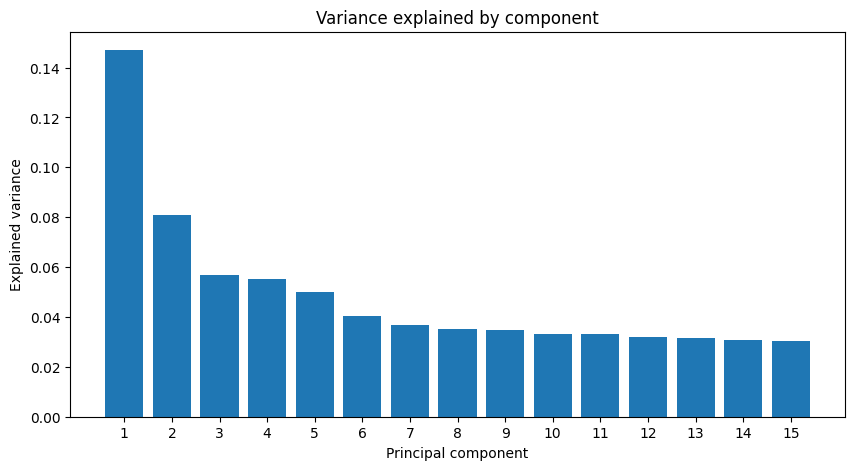

In [33]:
components = list(range(1, n_comp + 1))
variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))

plt.bar(components, variance)

plt.xlabel('Principal component')
plt.ylabel('Explained variance')
plt.title('Variance explained by component')

plt.xticks(components)

plt.show()

### Principal Component Analysis (PCA)

Based on the results obtained from the PCA analysis, it can be observed that there is no dominant principal component capable of explaining, on its own, a significant proportion of the total variability in the dataset. The first principal component explains approximately 14.7% of the variance, while subsequent components show a gradual decrease in their explanatory power.

Additionally, to account for approximately 75% of the cumulative variance, it was necessary to retain 15 principal components, indicating that the information in the dataset is distributed across multiple dimensions and variables.

Because of this, applying PCA does not result in a sufficiently significant reduction in dimensionality for this problem, and it also reduces the interpretability of the data by transforming the original variables into abstract components. For this reason, it is more appropriate to retain the original attributes previously selected during the exploratory data analysis when developing the predictive model.

In [34]:
pca.components_

array([[ 2.85690855e-01, -1.14080831e-01,  5.43212526e-04,
        -4.31082072e-03,  4.64647225e-03,  3.78232397e-03,
         7.89567633e-02, -2.22804352e-02,  8.40959428e-03,
        -2.47098658e-02, -9.36133343e-03,  4.65938435e-03,
         3.81394321e-01, -6.94600395e-02, -4.56693412e-03,
        -5.87258443e-02,  3.73402688e-01,  3.28481485e-03,
         5.18468835e-02, -9.28509332e-03, -9.82934701e-03,
         3.85477432e-03,  1.51275587e-02,  3.29221670e-02,
         4.02866469e-01, -1.28114897e-02,  1.20195731e-02,
         3.77590091e-01,  3.28061433e-01,  2.88152667e-01,
         3.20796869e-01,  4.05507296e-02],
       [ 3.94977295e-01, -4.12660729e-02,  4.41211843e-02,
         4.58285028e-02, -9.63876037e-02, -9.48531146e-03,
         1.28409513e-01, -3.33008437e-02,  7.33158696e-03,
        -3.27360290e-03,  3.47563479e-02,  3.43703812e-02,
         1.29679942e-01, -1.12270349e-01, -1.01326288e-02,
        -7.44308372e-02,  1.40234484e-01,  4.20440215e-02,
         3.42

In [35]:
#loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=modified_date.columns
)

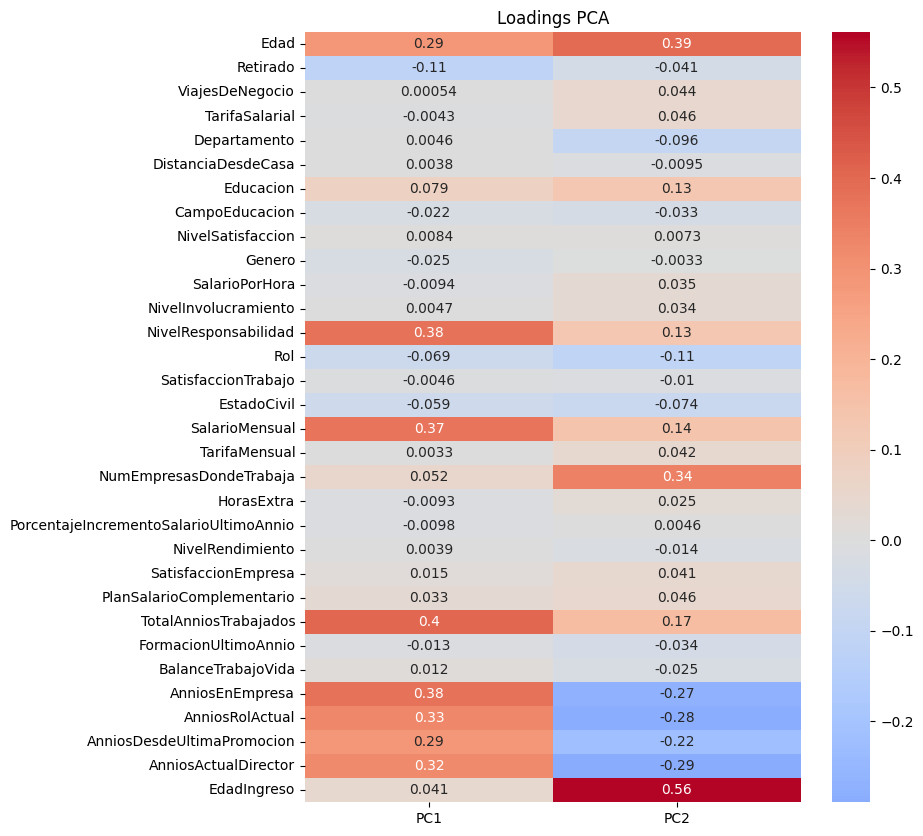

In [36]:
import seaborn as sns

plt.figure(figsize=(8,10))

sns.heatmap(
    loadings[['PC1', 'PC2']],
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Loadings PCA')
plt.show()

# 5. Conclusions and Recommendations

The data preparation process allowed the identification and correction of several quality issues, including duplicate records, missing values, inconsistent categorical labels, and variables with formats unsuitable for analysis. Additionally, categorical variables were encoded and numerical attributes were standardized to ensure compatibility with dimensionality reduction techniques and future predictive models.

The exploratory analysis provided useful insights into the structure and distribution of the employee data, enabling the selection of relevant attributes associated with employee turnover. Furthermore, the creation and transformation of variables improved the consistency and usability of the dataset for machine learning applications.

Although PCA allowed for a partial reduction in dimensionality and enabled an analysis of the data structure, the results show that the information is distributed across multiple dimensions, requiring a considerable number of components to account for an adequate proportion of the variance. Because of this and the loss of interpretability associated with the principal components, it is concluded that for this turnover prediction problem, it is more appropriate to retain the original attributes selected during the exploratory analysis.

As a next step, the processed dataset can be used to train and evaluate supervised machine learning models focused on predicting employee turnover and identifying the factors most strongly associated with employee retention.